In [1]:
!pip install yfinance

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = yf.download('ITC', start='2018-01-01', end='2024-01-01')
df.head()

/tmp/ipykernel_3738/715171399.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('ITC', start='2018-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,ITC,ITC,ITC,ITC,ITC
Date,,,,,
2018-01-02,30.841101,30.926100,30.161400,30.161400,176478
2018-01-03,31.435900,31.520800,30.756201,31.265900,218100
2018-01-04,30.586201,31.690701,30.416300,31.690701,201022
2018-01-05,14750.000000,14850.000000,14000.000000,14000.000000,1020
2018-01-08,31.011000,31.265900,30.841101,31.265900,63560


In [7]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [11]:

data = df[['Close']].values

In [12]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [13]:
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size-60:]

In [14]:
X_train = []
y_train = []

for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [15]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=5, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0638
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0608
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0582
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0547
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0478


In [16]:
X_test = []
y_test = data[train_size:]

for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step


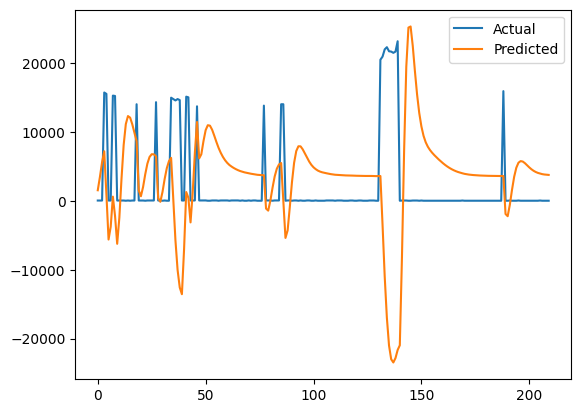

In [17]:
plt.plot(data[train_size:], label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.show()

In [18]:
last_60_days = scaled_data[-60:]
last_60_days = np.reshape(last_60_days, (1, 60, 1))

next_price = model.predict(last_60_days)
next_price = scaler.inverse_transform(next_price)

print(next_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
3728.9023
